# Home Loan Data Analysis

**Course-end Project 2 | IITK AIML Core: Deep Learning with Keras and TensorFlow**

**Objective:** Predict whether an applicant will repay a home loan (`TARGET`: 1 = default / payment difficulty, 0 = no difficulty) using historical data.

**Domain:** Finance

**Challenge:** Highly imbalanced target and a large feature set.

## 1. Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, recall_score, precision_score, f1_score
)
from imblearn.under_sampling import RandomUnderSampler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('TensorFlow:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow: 2.21.0


In [2]:
df = pd.read_csv('datasets/Home_loan_data.csv')
print(f'Shape: {df.shape}')
print(f'Number of features: {df.shape[1]}')
df.head()

Shape: (307511, 122)
Number of features: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Optional: peek data dictionary
try:
    dd = pd.read_csv('datasets/Data_Dictionary.csv', encoding='latin1')
    print('Data dictionary rows:', len(dd))
    display(dd.head(10))
except Exception as e:
    print('Could not load data dictionary:', e)

Data dictionary rows: 120


,Column no.,Variable Name,Description
0,1,SK_ID_CURR,Unique identifier for each client.
1,2,TARGET,"Whether the loan was repaid (1 for yes, 0 for ..."
2,3,NAME_CONTRACT_TYPE,"Type of loan contract (e.g., Cash loans, Revol..."
3,4,CODE_GENDER,Gender of the applicant.
4,5,FLAG_OWN_CAR,Whether the applicant owns a car (Yes/No).
5,6,FLAG_OWN_REALTY,Whether the applicant owns a house or flat (Ye...
6,7,CNT_CHILDREN,Number of children the applicant has.
7,8,AMT_INCOME_TOTAL,Total income of the applicant.
8,9,AMT_CREDIT,Total credit amount of the loan.
9,10,AMT_ANNUITY,Loan annuity (monthly payment).


## 2. Check for Null Values

Columns with missing values: 67 / 122


Total missing cells: 9152465


,missing,pct
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


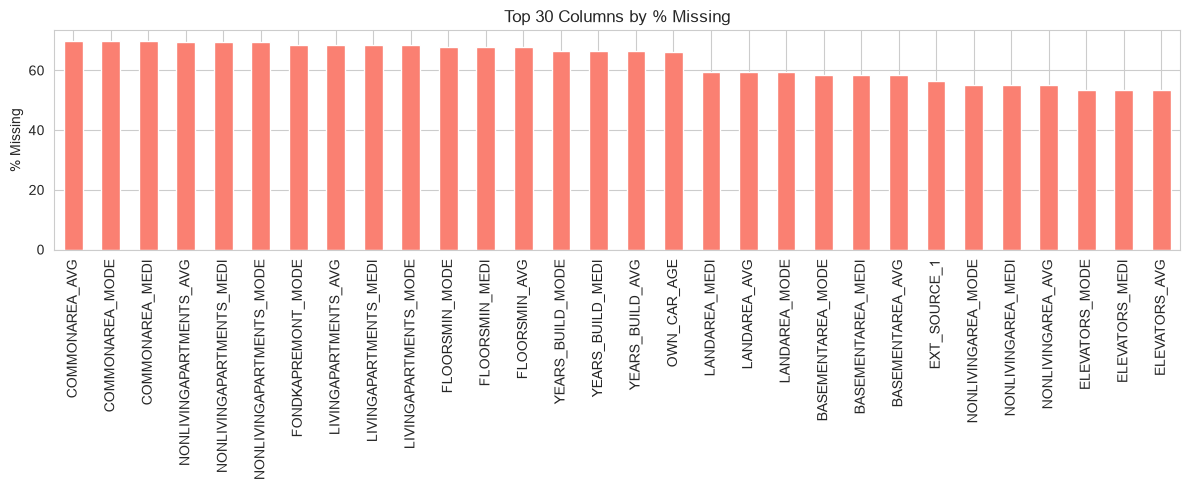

In [4]:
null_counts = df.isna().sum()
null_pct = (null_counts / len(df) * 100).sort_values(ascending=False)
null_summary = pd.DataFrame({'missing': null_counts, 'pct': null_pct}).loc[null_pct > 0].sort_values('pct', ascending=False)
print(f'Columns with missing values: {len(null_summary)} / {df.shape[1]}')
print(f'Total missing cells: {df.isna().sum().sum()}')
display(null_summary.head(25))

plt.figure(figsize=(12, 5))
null_summary['pct'].head(30).plot(kind='bar', color='salmon')
plt.title('Top 30 Columns by % Missing')
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()

## 3. Percentage of Default vs Payer (`TARGET`)

TARGET counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentage:
  Payers (TARGET=0):  91.93%
  Defaults (TARGET=1): 8.07%

Default-to-payer ratio: 1 : 11.39


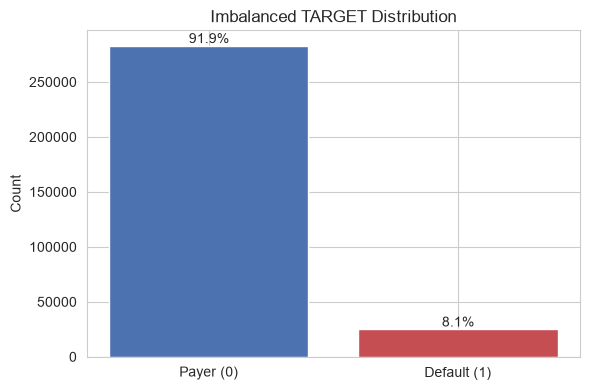

In [5]:
# TARGET: 1 = client with payment difficulties (default), 0 = all other cases
target_counts = df['TARGET'].value_counts().sort_index()
target_pct = df['TARGET'].value_counts(normalize=True).sort_index() * 100

print('TARGET counts:')
print(target_counts)
print('\nPercentage:')
print(f'  Payers (TARGET=0):  {target_pct[0]:.2f}%')
print(f'  Defaults (TARGET=1): {target_pct[1]:.2f}%')
print(f'\nDefault-to-payer ratio: 1 : {target_counts[0]/target_counts[1]:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Payer (0)', 'Default (1)'], target_counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title('Imbalanced TARGET Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f'{target_pct.iloc[i]:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 4. Preprocessing — Drop High-Null Columns, Impute, Encode

In [6]:
# Drop ID and columns with >40% missing
high_null_cols = null_pct[null_pct > 40].index.tolist()
drop_cols = ['SK_ID_CURR'] + high_null_cols
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f'Dropped {len(drop_cols)} columns (ID + >40% null). Remaining: {df_clean.shape}')

# Separate features / target
y = df_clean['TARGET'].astype(int)
X = df_clean.drop(columns=['TARGET'])

# Identify categorical vs numeric
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print(f'Categorical: {len(cat_cols)}, Numeric: {len(num_cols)}')

# Impute numeric with median, categorical with mode
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode().iloc[0])

print('Remaining missing:', X.isna().sum().sum())

Dropped 50 columns (ID + >40% null). Remaining: (307511, 72)
Categorical: 12, Numeric: 59


Remaining missing: 0


In [7]:
# Encode categoricals (LabelEncoder for compactness with many categories)
X_enc = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))

print('Encoded feature matrix:', X_enc.shape)
X_enc.head()

Encoded feature matrix: (307511, 71)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,6,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,1,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,6,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,6,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,6,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Balance the Dataset & Plot

Before balancing: [282686  24825]
After RandomUnderSampler: [24825 24825]
Balanced shape: (49650, 71)


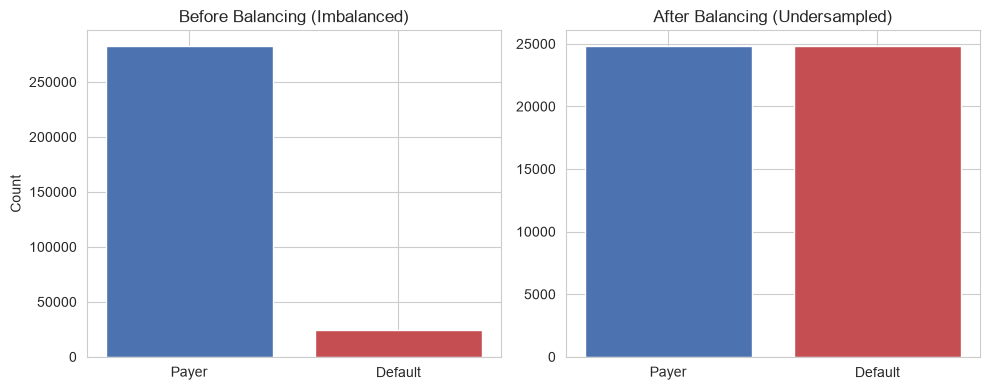

In [8]:
print('Before balancing:', np.bincount(y))

# Undersample majority class for a balanced training set (handles large volume)
rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X_enc, y)

print('After RandomUnderSampler:', np.bincount(y_bal))
print(f'Balanced shape: {X_bal.shape}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Payer', 'Default'], np.bincount(y), color=['#4C72B0', '#C44E52'])
axes[0].set_title('Before Balancing (Imbalanced)')
axes[0].set_ylabel('Count')
axes[1].bar(['Payer', 'Default'], np.bincount(y_bal), color=['#4C72B0', '#C44E52'])
axes[1].set_title('After Balancing (Undersampled)')
plt.tight_layout()
plt.show()

## 6. Train/Test Split & Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print('Train class counts:', np.bincount(y_train))
print('Test class counts:', np.bincount(y_test))

Train: (39720, 71), Test: (9930, 71)
Train class counts: [19860 19860]
Test class counts: [4965 4965]


## 7. Deep Learning Model (Keras + TensorFlow)

In [10]:
n_features = X_train_s.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='home_loan_default_nn')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='sensitivity')  # Recall = Sensitivity for binary default class
    ]
)
model.summary()

Model: "home_loan_default_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,353 (79.50 KB)

 Trainable params: 19,969 (78.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
early = keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=6, restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

Epoch 1/40


  1/125 ━━━━━━━━━━━━━━━━━━━━ 3:03 1s/step - accuracy: 0.5234 - auc: 0.5411 - loss: 0.7983 - sensitivity: 0.4275

 44/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5671 - auc: 0.5957 - loss: 0.7391 - sensitivity: 0.5301 

 88/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5906 - auc: 0.6225 - loss: 0.7103 - sensitivity: 0.5780

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6006 - auc: 0.6345 - loss: 0.6976 - sensitivity: 0.5899 - val_accuracy: 0.6498 - val_auc: 0.7074 - val_loss: 0.6370 - val_sensitivity: 0.6657


...

Epoch 33/40


  1/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7070 - auc: 0.7622 - loss: 0.5851 - sensitivity: 0.6957

 43/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6920 - auc: 0.7565 - loss: 0.5881 - sensitivity: 0.6920

 85/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6936 - auc: 0.7587 - loss: 0.5853 - sensitivity: 0.6928

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6932 - auc: 0.7587 - loss: 0.5849 - sensitivity: 0.6895 - val_accuracy: 0.6678 - val_auc: 0.7284 - val_loss: 0.6141 - val_sensitivity: 0.6693


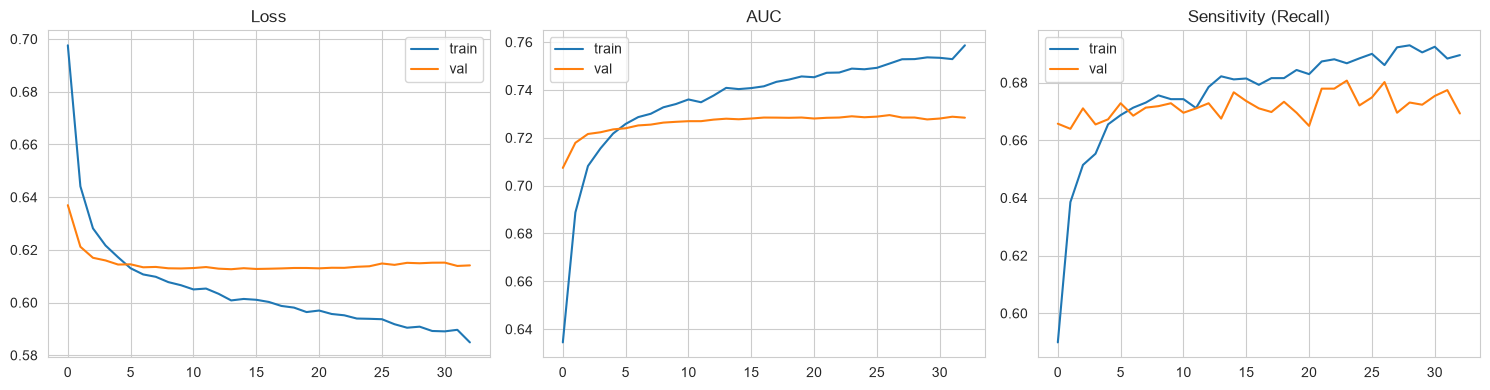

In [12]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist['loss'], label='train'); axes[0].plot(hist['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(hist['auc'], label='train'); axes[1].plot(hist['val_auc'], label='val')
axes[1].set_title('AUC'); axes[1].legend()
axes[2].plot(hist['sensitivity'], label='train'); axes[2].plot(hist['val_sensitivity'], label='val')
axes[2].set_title('Sensitivity (Recall)'); axes[2].legend()
plt.tight_layout()
plt.show()

## 8. Sensitivity & ROC-AUC

In [13]:
y_prob = model.predict(X_test_s).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Sensitivity = True Positive Rate = Recall for the positive (default) class
sensitivity = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(classification_report(y_test, y_pred, target_names=['Payer', 'Default']))
print(f'Accuracy    : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision   : {precision_score(y_test, y_pred):.4f}')
print(f'Sensitivity : {sensitivity:.4f}   ← required metric')
print(f'F1          : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC     : {auc:.4f}   ← required metric')

  1/311 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step

214/311 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step


              precision    recall  f1-score   support

       Payer       0.70      0.66      0.68      4965
     Default       0.68      0.71      0.69      4965

    accuracy                           0.69      9930
   macro avg       0.69      0.69      0.69      9930
weighted avg       0.69      0.69      0.69      9930

Accuracy    : 0.6857
Precision   : 0.6766
Sensitivity : 0.7116   ← required metric
F1          : 0.6936
ROC-AUC     : 0.7442   ← required metric


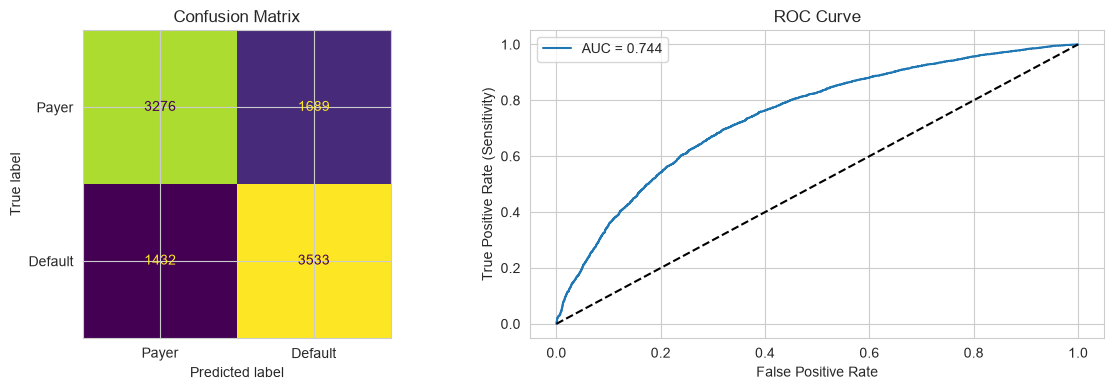

Sensitivity check: TP/(TP+FN) = 3533/(3533+1432) = 0.7116


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Payer', 'Default']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Sensitivity check: TP/(TP+FN) = {tp}/({tp}+{fn}) = {tp/(tp+fn):.4f}')

## 9. Summary

1. **Loaded** Home Credit–style loan application data (~300k rows, 122 columns).
2. **Null analysis:** Dropped columns with >40% missing; median/mode imputation for the rest.
3. **TARGET imbalance:** Reported default vs payer percentages (highly skewed toward payers).
4. **Balancing:** Random undersampling of the majority class; plotted before/after.
5. **Encoding:** Label-encoded categorical columns for the neural net.
6. **Model:** Keras DNN with BatchNorm + Dropout.
7. **Metrics:** **Sensitivity (Recall)** and **ROC-AUC** computed on the test set.

**Deliverable:** `Home_Loan_Data_Analysis.ipynb`